#Blood Cancer - Image Dataset
This dataset contains 10,000 single-cell images (64x64 pixels) taken from peripheral blood smears of patients diagnosed with Acute Myeloid Leukemia (Blood Cancer).



#Blood Cells Image Dataset

The dataset comprises 17,092 labeled images of normal peripheral blood cells, obtained using the CellaVision DM96 analyzer at the Hospital Clinic of Barcelona. It's organized into eight categories:

##Neutrophils:
Cells involved in the body's immune response to infection, characterized by multi-lobed nuclei and granulated cytoplasm.
##Eosinophils:
Cells implicated in allergic reactions and parasitic infections, recognizable by their bi-lobed nuclei and eosinophilic granules.
##Basophils:
Granulocytes with segmented nuclei and large, dark-staining cytoplasmic granules involved in allergic reactions and inflammation.
##Lymphocytes:
A diverse group of immune cells, including T cells, B cells, and natural killer cells, characterized by a large, round nucleus and minimal cytoplasm.
##Monocytes:
A type of white blood cell with a kidney-shaped nucleus and abundant cytoplasm, playing a role in immune response and inflammation.
##Immature Granulocytes:
Precursors to mature granulocytes, including promyelocytes, myelocytes, and metamyelocytes.
##Erythroblasts:
Immature red blood cells derived from bone marrow, characterized by a large nucleus and minimal cytoplasm.
##Platelets (Thrombocytes):
Small, disc-shaped cell fragments involved in blood clotting and wound healing.

In [1]:

import os
import time
import shutil
import pathlib
import itertools
from PIL import Image
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras import regularizers
import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"khizerz","key":"fbb6ddb69711c6da848ba6fe15643392"}'}

In [3]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d akhiljethwa/blood-cancer-image-dataset
!kaggle datasets download -d unclesamulus/blood-cells-image-dataset

Dataset URL: https://www.kaggle.com/datasets/akhiljethwa/blood-cancer-image-dataset
License(s): CC-BY-SA-3.0
  0% 0.00/102M [00:00<?, ?B/s]
100% 102M/102M [00:00<00:00, 1.36GB/s]
Dataset URL: https://www.kaggle.com/datasets/unclesamulus/blood-cells-image-dataset
License(s): CC-BY-SA-4.0
 93% 250M/268M [00:00<00:00, 733MB/s] 
100% 268M/268M [00:00<00:00, 792MB/s]


In [5]:
!unzip blood-cancer-image-dataset.zip
!unzip blood-cells-image-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: bloodcells_dataset/neutrophil/BNE_448273.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_44875.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_448776.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_449730.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_449915.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_450464.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_451701.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_451729.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_453088.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_454089.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_454943.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_455080.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_4555.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_455636.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_45575.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_456543

In [6]:

bloodcells_dataset_path = os.path.join(os.getcwd(), "bloodcells_dataset")

subdirectories = [os.path.join(bloodcells_dataset_path, d) for d in os.listdir(bloodcells_dataset_path) if os.path.isdir(os.path.join(bloodcells_dataset_path, d))]

for subdirectory in subdirectories:
    for filename in os.listdir(subdirectory):
        file_path = os.path.join(subdirectory, filename)
        new_file_path = os.path.join(bloodcells_dataset_path, filename)
        shutil.move(file_path, new_file_path)

    shutil.rmtree(subdirectory)


In [7]:

blood_cancer_path = os.path.join("Blood_Cancer")
files = os.listdir(blood_cancer_path)

for i, filename in enumerate(files):
    new_filename = "cancer" + str(i + 1) + ".jpg"
    os.rename(os.path.join(blood_cancer_path, filename), os.path.join(blood_cancer_path, new_filename))


In [8]:

bloodcells_dataset_path = os.path.join(os.getcwd(), "bloodcells_dataset")
files = os.listdir(bloodcells_dataset_path)

for i, filename in enumerate(files):
    new_filename = "non-cancer" + str(i + 1) + ".jpg"
    os.rename(os.path.join(bloodcells_dataset_path, filename), os.path.join(bloodcells_dataset_path, new_filename))


In [9]:


blood_cancer_path = os.path.join("Blood_Cancer")
files = os.listdir(blood_cancer_path)

for filename in files:
    if filename.endswith(".tiff"):
        image_path = os.path.join(blood_cancer_path, filename)
        image = Image.open(image_path)
        new_filename = filename.replace(".tiff", ".jpg")
        new_image_path = os.path.join(blood_cancer_path, new_filename)
        image.save(new_image_path)


In [10]:

blood_cancer_path = os.path.join(os.getcwd(), "Blood_Cancer")
bloodcells_dataset_path = os.path.join(os.getcwd(), "bloodcells_dataset")

merged_dataset_path = os.path.join(os.getcwd(), "merged_dataset")
os.mkdir(merged_dataset_path)


for filename in os.listdir(blood_cancer_path):
    shutil.copy(os.path.join(blood_cancer_path, filename), os.path.join(merged_dataset_path, filename))

for filename in os.listdir(bloodcells_dataset_path):
    shutil.copy(os.path.join(bloodcells_dataset_path, filename), os.path.join(merged_dataset_path, filename))

In [11]:

import pandas as pd

merged_dataset_path = os.path.join(os.getcwd(), "merged_dataset")

data = []

for filename in os.listdir(merged_dataset_path):
    if filename.endswith(".jpg"):
        if filename.startswith("cancer"):
            label = "cancer"
        else:
            label = "non-cancer"

        file_path = os.path.join(merged_dataset_path, filename)

        data.append({"file_path": file_path, "label": label})




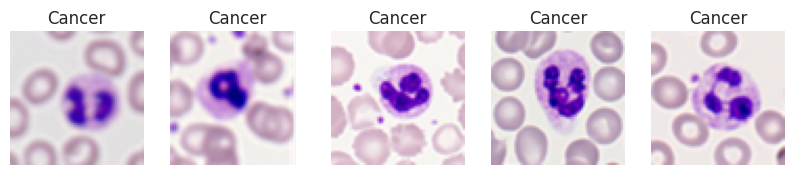

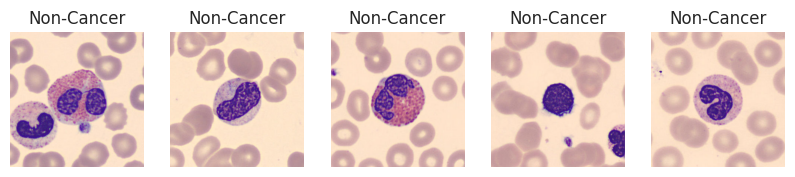

In [12]:


import matplotlib.pyplot as plt
# Assuming 'data' is a list of dictionaries with 'file_path' and 'label' keys
cancer_images = [d['file_path'] for d in data if d['label'] == 'cancer']
non_cancer_images = [d['file_path'] for d in data if d['label'] == 'non-cancer']

# Display a few cancer images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    image = Image.open(cancer_images[i])
    plt.imshow(image)
    plt.title('Cancer')
    plt.axis('off')
plt.show()

# Display a few non-cancer images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    image = Image.open(non_cancer_images[i])
    plt.imshow(image)
    plt.title('Non-Cancer')
    plt.axis('off')
plt.show()


In [13]:

df = pd.DataFrame(data)


In [14]:
df.head(5)

,file_path,label
0,/content/merged_dataset/cancer5279.jpg,cancer
1,/content/merged_dataset/cancer6507.jpg,cancer
2,/content/merged_dataset/non-cancer6624.jpg,non-cancer
3,/content/merged_dataset/non-cancer5697.jpg,non-cancer
4,/content/merged_dataset/non-cancer6056.jpg,non-cancer


# Checking Class imbalance

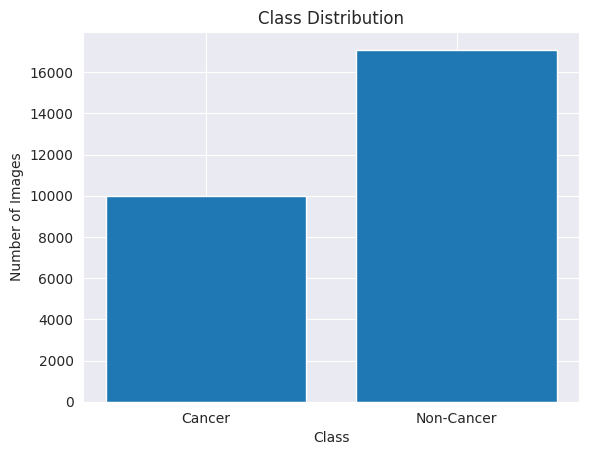

In [15]:

cancer_count = df[df["label"] == "cancer"].shape[0]
non_cancer_count = df[df["label"] == "non-cancer"].shape[0]

plt.bar(["Cancer", "Non-Cancer"], [cancer_count, non_cancer_count])
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.show()


# Resizing Image to 64 X 64

In [16]:

merged_dataset_path = os.path.join(os.getcwd(), "merged_dataset")


for filename in os.listdir(merged_dataset_path):

    if filename.endswith(".jpg"):

        file_path = os.path.join(merged_dataset_path, filename)


        image = cv2.imread(file_path)


        image = cv2.resize(image, (64, 64))

        cv2.imwrite(file_path, image)


In [17]:

resized_dataset_path = os.path.join(os.getcwd(), "merged_dataset")
for filename in os.listdir(resized_dataset_path):

    if filename.endswith(".jpg"):

        file_path = os.path.join(resized_dataset_path, filename)

        image = cv2.imread(file_path)

        if image.shape[0] != 64 or image.shape[1] != 64:
            print(f"Image {filename} is not 64x64.")
        else:
            print(f"Image {filename} is 64x64.")


Streaming output truncated to the last 5000 lines.
Image non-cancer17013.jpg is 64x64.
Image non-cancer7446.jpg is 64x64.
Image non-cancer2677.jpg is 64x64.
Image non-cancer9874.jpg is 64x64.
Image cancer1547.jpg is 64x64.
Image non-cancer12897.jpg is 64x64.
Image non-cancer9591.jpg is 64x64.
Image non-cancer3668.jpg is 64x64.
Image non-cancer12173.jpg is 64x64.
Image non-cancer1084.jpg is 64x64.
Image cancer5556.jpg is 64x64.
Image non-cancer7615.jpg is 64x64.
Image cancer2807.jpg is 64x64.
Image non-cancer16405.jpg is 64x64.
Image non-cancer16132.jpg is 64x64.
Image non-cancer13090.jpg is 64x64.
Image cancer6084.jpg is 64x64.
Image non-cancer15041.jpg is 64x64.
Image non-cancer1635.jpg is 64x64.
Image non-cancer9413.jpg is 64x64.
Image cancer5205.jpg is 64x64.
Image cancer1354.jpg is 64x64.
Image non-cancer7991.jpg is 64x64.
Image non-cancer10014.jpg is 64x64.
Image non-cancer9007.jpg is 64x64.
Image non-cancer661.jpg is 64x64.
Image cancer7570.jpg is 64x64.
Image non-cancer2887.jpg 

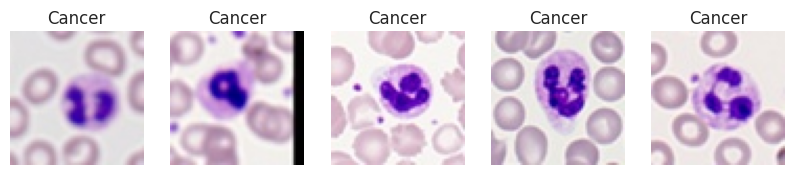

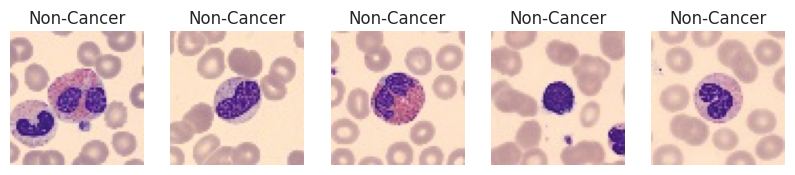

In [18]:


import matplotlib.pyplot as plt
# Assuming 'data' is a list of dictionaries with 'file_path' and 'label' keys
cancer_images = [d['file_path'] for d in data if d['label'] == 'cancer']
non_cancer_images = [d['file_path'] for d in data if d['label'] == 'non-cancer']

# Display a few cancer images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    image = Image.open(cancer_images[i])
    plt.imshow(image)
    plt.title('Cancer')
    plt.axis('off')
plt.show()

# Display a few non-cancer images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    image = Image.open(non_cancer_images[i])
    plt.imshow(image)
    plt.title('Non-Cancer')
    plt.axis('off')
plt.show()


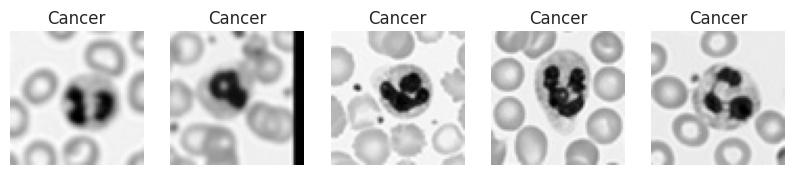

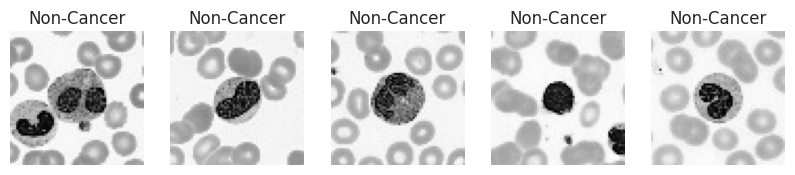

In [19]:

import matplotlib.pyplot as plt
merged_dataset_path = os.path.join(os.getcwd(), "merged_dataset")

for filename in os.listdir(merged_dataset_path):
    if filename.endswith(".jpg"):
        file_path = os.path.join(merged_dataset_path, filename)
        img = cv2.imread(file_path)
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        cv2.imwrite(file_path, img_gray)

# Assuming 'data' is a list of dictionaries with 'file_path' and 'label' keys
cancer_images = [d['file_path'] for d in data if d['label'] == 'cancer']
non_cancer_images = [d['file_path'] for d in data if d['label'] == 'non-cancer']

# Display a few cancer images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    image = Image.open(cancer_images[i])
    plt.imshow(image, cmap='gray')
    plt.title('Cancer')
    plt.axis('off')
plt.show()

# Display a few non-cancer images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    image = Image.open(non_cancer_images[i])
    plt.imshow(image, cmap='gray')
    plt.title('Non-Cancer')
    plt.axis('off')
plt.show()


In [20]:
df.head(5)

,file_path,label
0,/content/merged_dataset/cancer5279.jpg,cancer
1,/content/merged_dataset/cancer6507.jpg,cancer
2,/content/merged_dataset/non-cancer6624.jpg,non-cancer
3,/content/merged_dataset/non-cancer5697.jpg,non-cancer
4,/content/merged_dataset/non-cancer6056.jpg,non-cancer


In [21]:

merged_dataset_path = os.path.join(os.getcwd(), "merged_dataset")

for filename in os.listdir(merged_dataset_path):
    if filename.endswith(".jpg"):

        file_path = os.path.join(merged_dataset_path, filename)

        image = Image.open(file_path)

        image = image.convert("L")

        image.save(file_path)



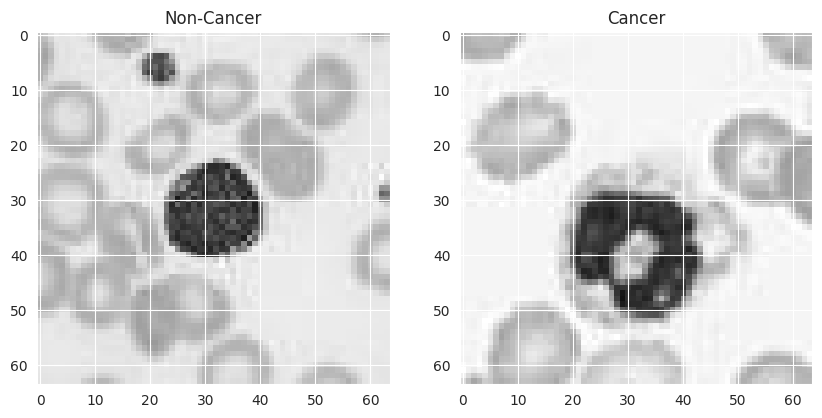

In [22]:

image_non_cancer = cv2.imread(os.path.join(merged_dataset_path, "non-cancer1.jpg"))
image_cancer = cv2.imread(os.path.join(merged_dataset_path, "cancer1.jpg"))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_non_cancer)
plt.title("Non-Cancer")
plt.subplot(1, 2, 2)
plt.imshow(image_cancer)
plt.title("Cancer")
plt.show()

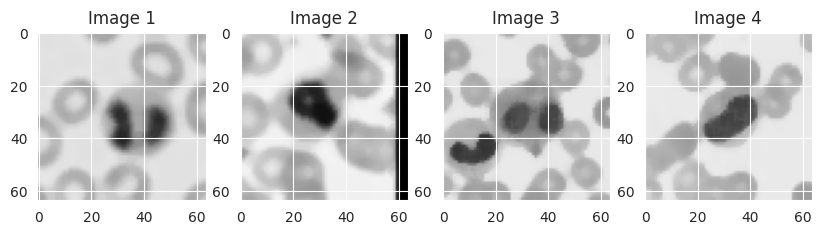

In [23]:


import matplotlib.pyplot as plt
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

def remove_noise(image):

  denoised_image = cv2.medianBlur(image, 5)
  return denoised_image


images_path = [os.path.join(merged_dataset_path, filename) for filename in os.listdir(merged_dataset_path) if filename.endswith(".jpg")]


denoised_images = []
for image_path in images_path:
  image = cv2.imread(image_path)
  denoised_image = remove_noise(image)
  denoised_images.append(denoised_image)

plt.figure(figsize=(10, 5))
for i in range(4):
  plt.subplot(1, 4, i+1)
  plt.imshow(denoised_images[i])
  plt.title(f"Image {i+1}")
plt.show()


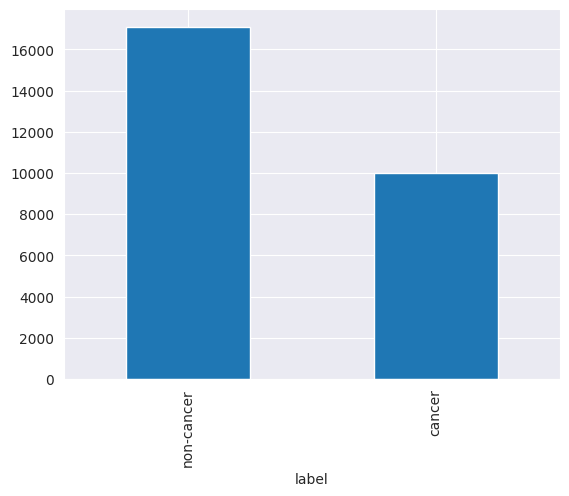

In [24]:

import matplotlib.pyplot as plt
df["label"].value_counts().plot(kind="bar")
plt.show()


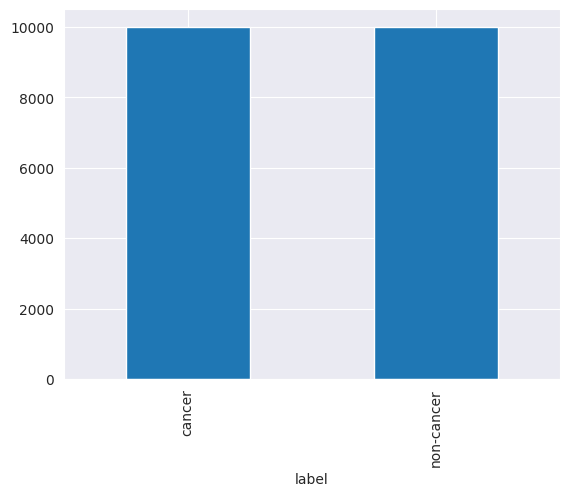

In [25]:

df_cancer = df[df["label"] == "cancer"]
df_non_cancer = df[df["label"] == "non-cancer"].sample(n=len(df_cancer))
df_balanced = pd.concat([df_cancer, df_non_cancer]).reset_index(drop=True)

df_balanced["label"].value_counts().plot(kind="bar")
plt.show()


In [26]:

df_balanced["label"] = df_balanced["label"].apply(lambda x: 0 if x == "non-cancer" else 1)


In [27]:

# image_paths = df_balanced["file_path"].tolist()
# labels = df_balanced["label"].tolist()


# train_paths, test_paths, train_labels, test_labels = train_test_split(image_paths, labels, test_size=0.2, random_state=42)


# def load_image(image_path):
#   image = cv2.imread(image_path)
#   image = cv2.resize(image, (64, 64))
#   image = image.astype("float32") / 255.0
#   return image

# train_images = [load_image(path) for path in train_paths]
# test_images = [load_image(path) for path in test_paths]


# train_images = np.array(train_images)
# test_images = np.array(test_images)
# train_labels = np.array(train_labels)
# test_labels = np.array(test_labels)


In [28]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
import cv2

# Convert file paths and labels to lists
image_paths = df_balanced["file_path"].tolist()
labels = df_balanced["label"].tolist()

# Convert labels to numpy array for compatibility
labels = np.array(labels)
image_paths = np.array(image_paths)

# Define number of folds
n_splits = 5  # you can set to 10 if dataset is large

# Initialize KFold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

def load_image(image_path):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (64, 64))
    image = image.astype("float32") / 255.0
    return image

fold = 1
for train_index, val_index in skf.split(image_paths, labels):
    print(f"\n📂 Fold {fold}")

    # Split paths and labels
    train_paths, val_paths = image_paths[train_index], image_paths[val_index]
    train_labels, val_labels = labels[train_index], labels[val_index]

    # Load images
    train_images = np.array([load_image(p) for p in train_paths])
    val_images = np.array([load_image(p) for p in val_paths])

    # Convert labels
    train_labels = np.array(train_labels)
    val_labels = np.array(val_labels)

    # 🧠 Now train your model here for this fold using train_images, train_labels
    # Example:
    # model.fit(train_images, train_labels, ...)
    # val_preds = model.predict(val_images)
    # accuracy = compute_accuracy(val_preds, val_labels)

    fold += 1



📂 Fold 1

📂 Fold 2

📂 Fold 3

📂 Fold 4

📂 Fold 5


In [33]:


def build_cnn_model(input_shape=(64, 64, 3)):
    model = Sequential()

    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(1, activation='sigmoid')) # Binary classification

    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    return model

fold = 1
for train_index, val_index in skf.split(image_paths, labels):
    print(f"\n📂 Fold {fold}")

    # Split paths and labels
    train_paths, val_paths = image_paths[train_index], image_paths[val_index]
    train_labels, val_labels = labels[train_index], labels[val_index]

    # Load images
    train_images = np.array([load_image(p) for p in train_paths])
    val_images = np.array([load_image(p) for p in val_paths])

    # Convert labels
    train_labels = np.array(train_labels)
    val_labels = np.array(val_labels)

    # Build and train the model
    model = build_cnn_model()
    history = model.fit(train_images, train_labels, epochs=10, batch_size=32, validation_data=(val_images, val_labels))

    # Evaluate the model on the validation set
    loss, accuracy = model.evaluate(val_images, val_labels, verbose=0)
    print(f"Fold {fold} Validation Loss: {loss:.4f}, Validation Accuracy: {accuracy:.4f}")

    fold += 1



📂 Fold 1
Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8766 - loss: 0.2367 - val_accuracy: 0.9990 - val_loss: 0.0030
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9983 - loss: 0.0052 - val_accuracy: 0.9992 - val_loss: 0.0043
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9967 - loss: 0.0108 - val_accuracy: 0.9992 - val_loss: 0.0028
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 0.9678 - val_loss: 0.0773
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9935 - loss: 0.0194 - val_accuracy: 0.9950 - val_loss: 0.0184
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9964 - loss: 0.0097 - val_accuracy: 0.9998 - val_loss: 0.0026
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9950 - loss: 0.0152 - val_accuracy: 0.9987 - val_loss: 0.0049
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9995 - loss: 0.0013 - val_a

In [34]:
import numpy as np

val_accuracies = [0.9975, 0.9998, 1.0000, 0.9987, 0.9987]
val_losses = [0.0089, 0.0030, 0.0002, 0.0028, 0.0042]

mean_acc = np.mean(val_accuracies)
std_acc = np.std(val_accuracies)

mean_loss = np.mean(val_losses)
std_loss = np.std(val_losses)

print(f"Mean Validation Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
print(f"Mean Validation Loss: {mean_loss:.4f} ± {std_loss:.4f}")


Mean Validation Accuracy: 0.9989 ± 0.0009
Mean Validation Loss: 0.0038 ± 0.0029


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


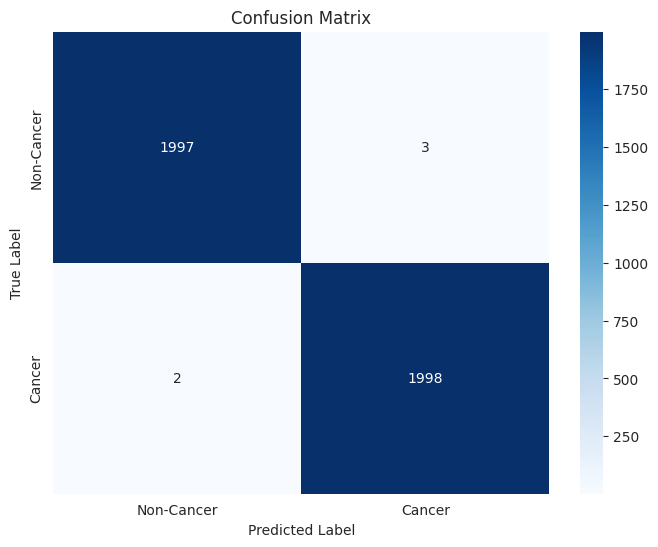

In [36]:

from sklearn.metrics import confusion_matrix

# Get predictions for the validation data
val_predictions = model.predict(val_images)
val_predicted_classes = (val_predictions > 0.5).astype(int) # Convert probabilities to binary class predictions

cm = confusion_matrix(val_labels, val_predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Cancer', 'Cancer'], yticklabels=['Non-Cancer', 'Cancer'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


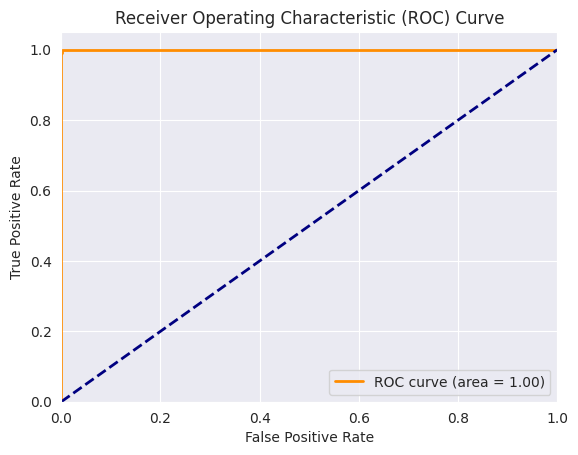

ROC AUC Score: 1.0000


In [37]:
from sklearn.metrics import roc_curve, auc

val_probabilities = model.predict(val_images).ravel() # Flatten to a 1D array

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(val_labels, val_probabilities)

# Compute ROC AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Images the model is confident about:


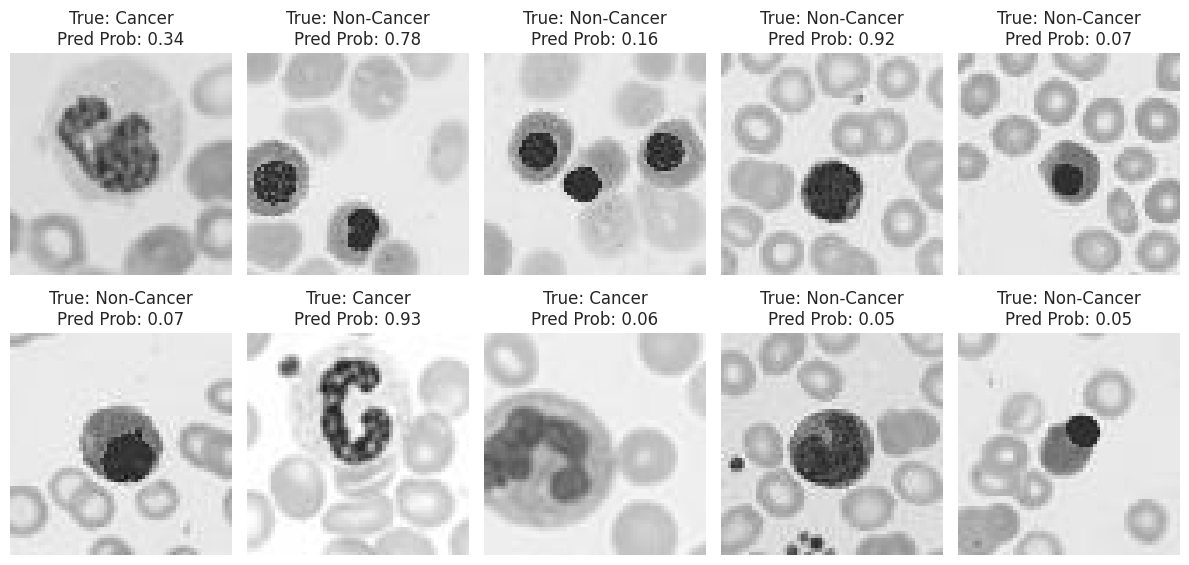


Images the model is least confident about:


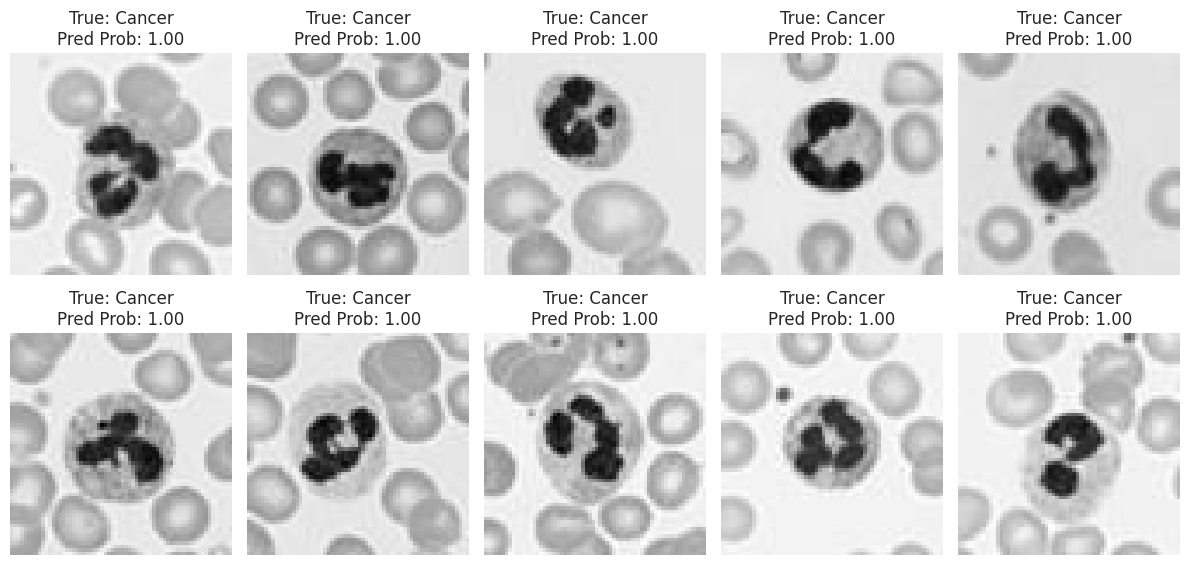

In [38]:


val_predictions = model.predict(val_images)


confidence = np.abs(val_predictions - 0.5)
sorted_indices = np.argsort(confidence.flatten())


sorted_val_images = val_images[sorted_indices]
sorted_val_labels = val_labels[sorted_indices]
sorted_val_predictions = val_predictions[sorted_indices]

print("Images the model is confident about:")
plt.figure(figsize=(12, 6))
for i in range(10): # Display top 10 most confident images
    plt.subplot(2, 5, i + 1)
    plt.imshow(sorted_val_images[i])
    true_label = "Cancer" if sorted_val_labels[i] == 1 else "Non-Cancer"
    predicted_prob = sorted_val_predictions[i][0]
    plt.title(f"True: {true_label}\nPred Prob: {predicted_prob:.2f}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Display images with low confidence
print("\nImages the model is least confident about:")
plt.figure(figsize=(12, 6))
for i in range(10): # Display bottom 10 least confident images
    plt.subplot(2, 5, i + 1)
    plt.imshow(sorted_val_images[-i-1])
    true_label = "Cancer" if sorted_val_labels[-i-1] == 1 else "Non-Cancer"
    predicted_prob = sorted_val_predictions[-i-1][0]
    plt.title(f"True: {true_label}\nPred Prob: {predicted_prob:.2f}")
    plt.axis('off')
plt.tight_layout()
plt.show()

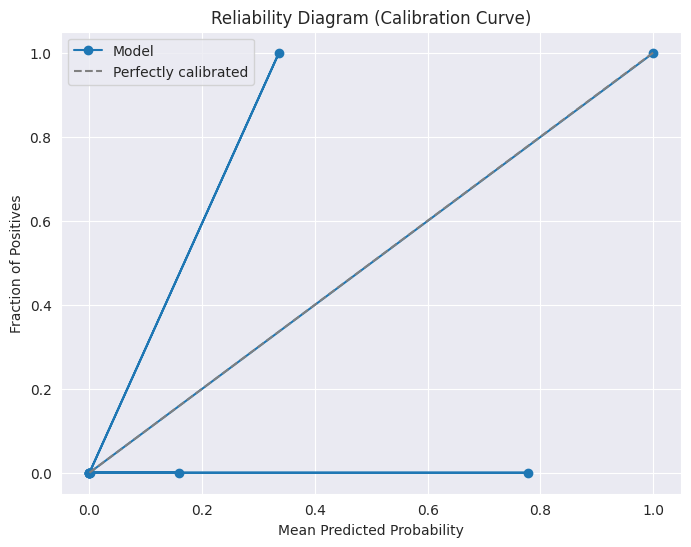

Expected Calibration Error (ECE): 0.0010


In [39]:
def plot_reliability_curve(y_true, y_prob, n_bins=10):
    """
    Plots a reliability diagram (calibration curve) for evaluating model calibration.

    Args:
        y_true (np.ndarray): Array of true binary labels (0 or 1).
        y_prob (np.ndarray): Array of predicted probabilities for the positive class.
        n_bins (int): Number of bins to use for partitioning the predicted probabilities.
    """
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

    fraction_of_positives = np.zeros(n_bins)
    mean_predicted_value = np.zeros(n_bins)
    sample_counts = np.zeros(n_bins)

    for i in range(n_bins):
        # Define the range for the current bin
        if i == n_bins - 1:
            bin_indices = np.where((y_prob >= bin_edges[i]) & (y_prob <= bin_edges[i+1]))
        else:
            bin_indices = np.where((y_prob >= bin_edges[i]) & (y_prob < bin_edges[i+1]))

        bin_true = y_true[bin_indices]
        bin_prob = y_prob[bin_indices]

        sample_counts[i] = len(bin_true)
        if sample_counts[i] > 0:
            fraction_of_positives[i] = np.mean(bin_true)
            mean_predicted_value[i] = np.mean(bin_prob)

    plt.figure(figsize=(8, 6))
    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', linestyle='-', label='Model')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title('Reliability Diagram (Calibration Curve)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Calculate Expected Calibration Error (ECE)
    non_empty_bins = sample_counts > 0
    ece = np.sum((sample_counts[non_empty_bins] / np.sum(sample_counts)) * np.abs(fraction_of_positives[non_empty_bins] - mean_predicted_value[non_empty_bins]))
    print(f"Expected Calibration Error (ECE): {ece:.4f}")


# Assuming you have val_labels and val_predictions (probabilities) from your model evaluation
plot_reliability_curve(val_labels, val_predictions.flatten(), n_bins=10)


The metrics indicate an excellent performance of the model with very high precision, recall, and F1 score, suggesting that the model makes very few errors in both false positives and false negatives.